In [284]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from copy import deepcopy

from farmers_intermediaries import Instance
from road_graphs import RoadGraph
import pickle
import pandas as pd
import pricing
from pricing import Optimizer
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

In [285]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

def plot_metric_by_instance(
    df,
    metric_col,
    metric_label=None,
    n_cols=4,
    figsize_per_panel=(4.2, 3.2),
    plot_quadratic=True,
):
    metric_label = metric_label or metric_col

    instances = sorted(df["instance"].unique())
    epsilons = sorted(df["avg_epsilon"].unique())

    n_instances = len(instances)
    n_rows = math.ceil(n_instances / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        sharex=True,
        sharey=True,
    )

    axes = np.array(axes).reshape(-1)

    for ax, instance_id in zip(axes, instances):
        inst_df = df[df["instance"] == instance_id].copy()

        for eps in epsilons:
            g = (
                inst_df[inst_df["avg_epsilon"] == eps]
                .groupby("scale_factor", as_index=False)[metric_col]
                .mean()
                .sort_values("scale_factor")
            )

            if g.empty:
                continue

            x = g["scale_factor"].to_numpy()
            y = g[metric_col].to_numpy()

            ax.plot(x, y, marker="o", label=f"ε={eps}", linewidth=1.5)

            if plot_quadratic and len(g) >= 3:
                x_centered = x - x.mean()
                coef = np.polyfit(x_centered, y, deg=2)

                x_smooth = np.linspace(x.min(), x.max(), 100)
                x_smooth_centered = x_smooth - x.mean()
                y_smooth = np.polyval(coef, x_smooth_centered)

                ax.plot(x_smooth, y_smooth, linestyle="--", linewidth=1, alpha=0.6)

        ax.set_title(f"Instance {instance_id}", fontsize=10)
        ax.grid(True, alpha=0.3)

    for ax in axes[n_instances:]:
        ax.axis("off")

    fig.supxlabel("Scale factor")
    fig.supylabel(metric_label)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="epsilon", loc="upper center", ncol=len(epsilons))

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

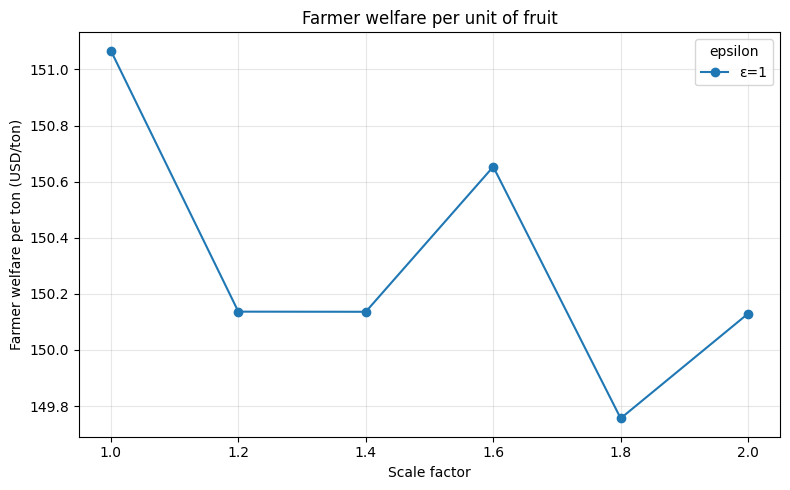

In [329]:
json_files = {}
directory = "../data/results_scale_farmers_local_low"

for filename in os.listdir(directory):
    if filename.endswith(".json") and int(filename.split('.')[0]) < 6:
        filepath = os.path.join(directory, filename)
        with open(filepath, "r") as file:
            json_files[filename] = json.load(file)

gap_dict = []

USD = 14500.0
FRUIT_PRICE_IDR = 2513.0 * 1000.0

for name, result in json_files.items():
    farmer_quantities = np.array(list(result["farmer_quantities"].values()))
    total_quantity = farmer_quantities.sum()
    total_fruit_value_idr = total_quantity * FRUIT_PRICE_IDR
    total_fruit_value_usd = total_fruit_value_idr / USD

    n_farmers = result["summary_vanilla"]["instance"]["n_farmers"]

    sol = result["summary_vanilla"]["max_int_welf_sol"]

    profit_idr = sol["profit"]
    farmer_welfare_idr = sol["farmer_welfare"]
    intermediary_welfare_idr = sol["intermediary_welfare"]
    matching_cost_idr = sol["matching_cost"]

    gap_dict.append({
        "instance": result["instance_id"],
        "avg_epsilon": result["epsilon"],
        "scale_factor": result["scale_factor"],
        "n_farmers": n_farmers,
        "total_quantity": total_quantity,
        "avg_farmer_quantity": total_quantity / n_farmers,

        "fruit_value_idr": total_fruit_value_idr,
        "fruit_value_usd": total_fruit_value_usd,

        # Raw totals
        "platform_profit_idr": profit_idr,
        "farmer_welfare_idr": farmer_welfare_idr,
        "intermediary_welfare_idr": intermediary_welfare_idr,
        "matching_cost_idr": matching_cost_idr,

        "platform_profit_usd": profit_idr / USD,
        "farmer_welfare_usd": farmer_welfare_idr / USD,
        "intermediary_welfare_usd": intermediary_welfare_idr / USD,
        "matching_cost_usd": matching_cost_idr / USD,

        # Per-farmer quantities
        "revenue_per_farmer_usd": total_fruit_value_usd / n_farmers,
        "platform_profit_per_farmer_usd": (profit_idr / USD) / n_farmers,
        "farmer_welfare_per_farmer_usd": (farmer_welfare_idr / USD) / n_farmers,
        "intermediary_welfare_per_farmer_usd": (intermediary_welfare_idr / USD) / n_farmers,
        "matching_cost_per_farmer_usd": (matching_cost_idr / USD) / n_farmers,

        # Shares of total fruit value
        "profit_percentage": profit_idr / total_fruit_value_idr,
        "farmer_welfare_share": farmer_welfare_idr / total_fruit_value_idr,
        "intermediary_welfare_share": intermediary_welfare_idr / total_fruit_value_idr,
        "matching_cost_share": matching_cost_idr / total_fruit_value_idr,
    })

df_gaps = pd.DataFrame(gap_dict)

df_gaps["farmer_welfare_per_ton_usd"] = (
    df_gaps["farmer_welfare_usd"] / df_gaps["total_quantity"]
)

import matplotlib.pyplot as plt
import numpy as np

def summarize_by_scale(df, y_col, group_cols=("scale_factor", "avg_epsilon")):
    return (
        df
        .groupby(list(group_cols))
        .agg(
            mean=(y_col, "mean"),
            se=(y_col, lambda x: x.std(ddof=1) / np.sqrt(len(x))),
            n=(y_col, "size"),
        )
        .reset_index()
    )

summary = summarize_by_scale(
    df_gaps,
    "farmer_welfare_per_ton_usd"
)

plt.figure(figsize=(8, 5))

for eps, g in summary.groupby("avg_epsilon"):
    g = g.sort_values("scale_factor")

    x = g["scale_factor"]
    y = g["mean"]
    se = g["se"]

    plt.plot(x, y, marker="o", label=f"ε={eps}")
    plt.fill_between(x, y - 1.96 * se, y + 1.96 * se, alpha=0.2)

plt.xlabel("Scale factor")
plt.ylabel("Farmer welfare per ton (USD/ton)")
plt.title("Farmer welfare per unit of fruit")
plt.grid(alpha=0.3)
plt.legend(title="epsilon")
plt.tight_layout()
plt.show()

In [330]:
summary_fw = (
    df_gaps
    .groupby("scale_factor")
    .agg(
        mean_farmer_welfare_usd=("farmer_welfare_usd", "mean"),
        se_farmer_welfare_usd=("farmer_welfare_usd", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("farmer_welfare_usd", "size"),
    )
    .reset_index()
    .sort_values("scale_factor")
)

summary_fw

,scale_factor,mean_farmer_welfare_usd,se_farmer_welfare_usd,n
0,1.0,5438.398079,NaN,1
1,1.2,5404.912635,NaN,1
2,1.4,5404.896011,NaN,1
3,1.6,5408.444260,NaN,1
4,1.8,5361.269567,NaN,1
5,2.0,5374.641259,NaN,1


In [331]:
summary_fw["change_from_prev"] = summary_fw["mean_farmer_welfare_usd"].diff()
summary_fw["pct_change_from_prev"] = summary_fw["mean_farmer_welfare_usd"].pct_change()

summary_fw

,scale_factor,mean_farmer_welfare_usd,se_farmer_welfare_usd,n,change_from_prev,pct_change_from_prev
0,1.0,5438.398079,NaN,1,NaN,NaN
1,1.2,5404.912635,NaN,1,-33.485444,-0.006157
2,1.4,5404.896011,NaN,1,-0.016624,-0.000003
3,1.6,5408.444260,NaN,1,3.548249,0.000656
4,1.8,5361.269567,NaN,1,-47.174693,-0.008722
5,2.0,5374.641259,NaN,1,13.371692,0.002494


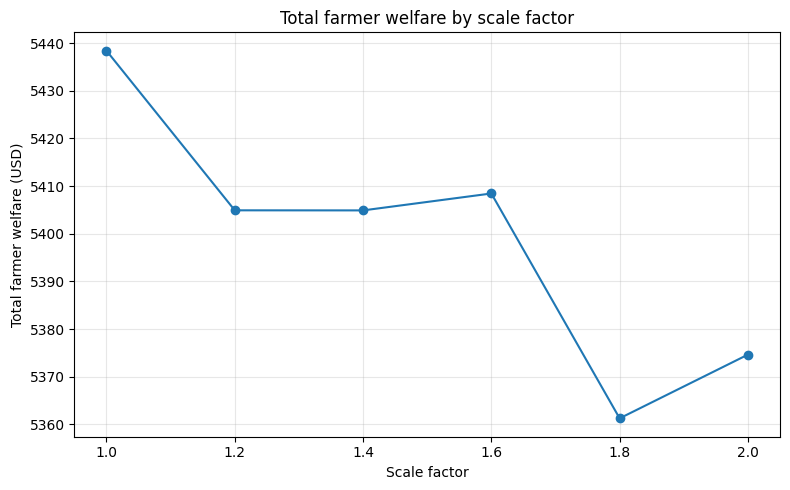

In [334]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

x = summary_fw["scale_factor"]
y = summary_fw["mean_farmer_welfare_usd"]
se = summary_fw["se_farmer_welfare_usd"]

plt.plot(x, y, marker="o")
plt.fill_between(x, y - 1.96 * se, y + 1.96 * se, alpha=0.2)

plt.xlabel("Scale factor")
plt.ylabel("Total farmer welfare (USD)")
plt.title("Total farmer welfare by scale factor")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [277]:
summary_q = (
    df_gaps
    .groupby("scale_factor")
    .agg(
        mean_total_quantity=("total_quantity", "mean"),
        se_total_quantity=("total_quantity", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("total_quantity", "size"),
    )
    .reset_index()
    .sort_values("scale_factor")
)

summary_q["change_from_prev"] = summary_q["mean_total_quantity"].diff()
summary_q["pct_change_from_prev"] = summary_q["mean_total_quantity"].pct_change()

summary_q

,scale_factor,mean_total_quantity,se_total_quantity,n,change_from_prev,pct_change_from_prev
0,1.0,35.9,NaN,1,NaN,NaN
1,1.2,40.9,NaN,1,5.0,0.139276
2,1.4,43.7,NaN,1,2.8,0.068460
3,1.6,47.3,NaN,1,3.6,0.082380
4,1.8,49.1,NaN,1,1.8,0.038055


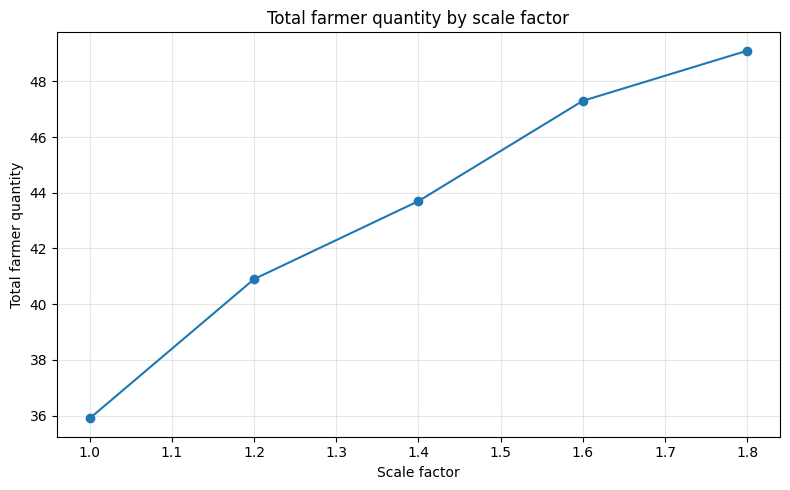

In [278]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

x = summary_q["scale_factor"]
y = summary_q["mean_total_quantity"]
se = summary_q["se_total_quantity"]

plt.plot(x, y, marker="o")
plt.fill_between(x, y - 1.96 * se, y + 1.96 * se, alpha=0.2)

plt.xlabel("Scale factor")
plt.ylabel("Total farmer quantity")
plt.title("Total farmer quantity by scale factor")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [279]:
df_gaps["farmer_welfare_per_ton_usd"] = (
    df_gaps["farmer_welfare_usd"] / df_gaps["total_quantity"]
)

summary_fw_per_ton = (
    df_gaps
    .groupby("scale_factor")
    .agg(
        mean=("farmer_welfare_per_ton_usd", "mean"),
        se=("farmer_welfare_per_ton_usd", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
    .reset_index()
)

In [280]:
summary_fw_per_ton

,scale_factor,mean,se
0,1.0,144.442219,NaN
1,1.2,146.103689,NaN
2,1.4,145.020077,NaN
3,1.6,143.605997,NaN
4,1.8,144.072114,NaN


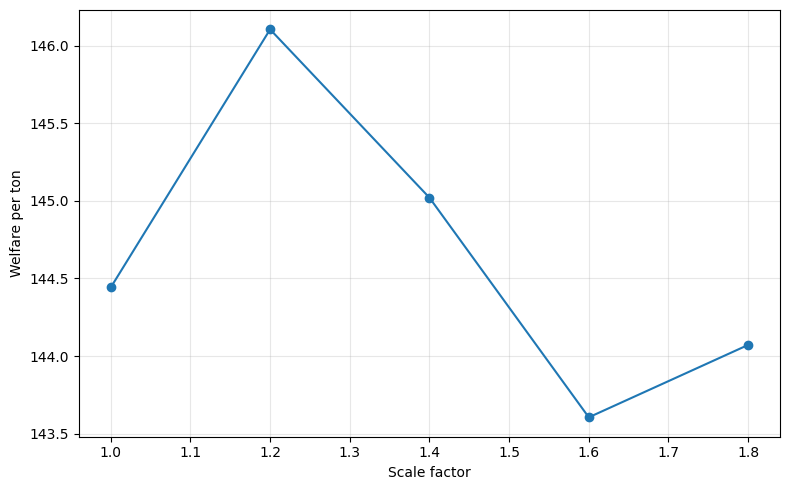

In [281]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

x = summary_fw_per_ton["scale_factor"]
y = summary_fw_per_ton["mean"]
se = summary_fw_per_ton["se"]

plt.plot(x, y, marker="o")
plt.fill_between(x, y - 1.96 * se, y + 1.96 * se, alpha=0.2)

plt.xlabel("Scale factor")
plt.ylabel("Welfare per ton")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: 'avg_epsilon'

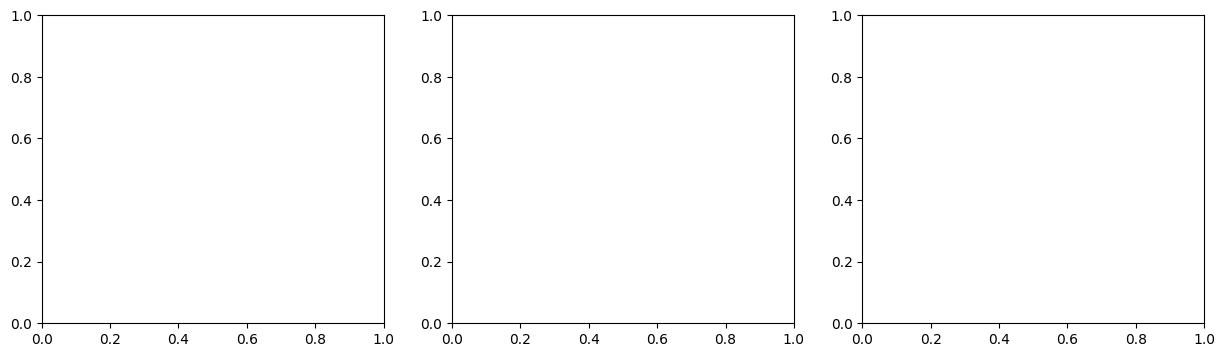

In [235]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for eps, g in summary_fw.groupby("avg_epsilon"):
    g = g.sort_values("scale_factor")
    axes[0].plot(g["scale_factor"], g["mean"], marker="o", label=f"ε={eps}")
axes[0].set_title("Total farmer welfare")
axes[0].set_xlabel("Scale factor")
axes[0].set_ylabel("USD")

for eps, g in summary_nf.groupby("avg_epsilon"):
    g = g.sort_values("scale_factor")
    axes[1].plot(g["scale_factor"], g["mean"], marker="o", label=f"ε={eps}")
axes[1].set_title("Number of farmers")
axes[1].set_xlabel("Scale factor")

for eps, g in summary_avg_q.groupby("avg_epsilon"):
    g = g.sort_values("scale_factor")
    axes[2].plot(g["scale_factor"], g["mean"], marker="o", label=f"ε={eps}")
axes[2].set_title("Average farmer quantity")
axes[2].set_xlabel("Scale factor")

for ax in axes:
    ax.grid(alpha=0.3)

axes[0].legend(title="epsilon")
plt.tight_layout()
plt.show()

In [236]:
df_gaps["revenue_per_farmer_usd"] = (
    df_gaps["fruit_value"] / df_gaps["n_farmers"]
)

df_gaps["farmer_welfare_per_farmer_usd"] = (
    df_gaps["farmer_welfare_usd"] / df_gaps["n_farmers"]
)

df_gaps["platform_profit_per_farmer_usd"] = (
    df_gaps["vanilla_profit"] / df_gaps["n_farmers"]
)

df_gaps["matching_cost_usd"] = (
    df_gaps["matching_cost"] * df_gaps["fruit_value"]
)

df_gaps["matching_cost_per_farmer_usd"] = (
    df_gaps["matching_cost_usd"] / df_gaps["n_farmers"]
)

df_gaps["intermediary_welfare_usd"] = (
    df_gaps["max_welfare_intermediaries"] * df_gaps["fruit_value"]
)

df_gaps["intermediary_welfare_per_farmer_usd"] = (
    df_gaps["intermediary_welfare_usd"] / df_gaps["n_farmers"]
)

KeyError: 'fruit_value'

In [237]:
def plot_welfare_range(df, lower_col, upper_col, ylabel, title):
    df_plot = df.copy()
    df_plot["avg_epsilon"] = df_plot["avg_epsilon"].astype(int)
    df_plot["n_farmers"] = df_plot["n_farmers"].astype(int)

    summary = (
        df_plot
        .groupby(["avg_epsilon", "n_farmers"], as_index=False)
        .agg(
            lower=(lower_col, "mean"),
            upper=(upper_col, "mean"),
        )
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    for eps, group in summary.groupby("avg_epsilon"):
        group = group.sort_values("n_farmers")

        ax.plot(
            group["n_farmers"],
            group["lower"],
            marker="o",
            linewidth=1.5,
            label=f"epsilon={eps}, lower"
        )

        ax.plot(
            group["n_farmers"],
            group["upper"],
            marker="o",
            linewidth=1.5,
            linestyle="--",
            label=f"epsilon={eps}, upper"
        )

        ax.fill_between(
            group["n_farmers"],
            group["lower"],
            group["upper"],
            alpha=0.12,
        )

    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    # ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_xlabel("Number of farmers")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(title="Welfare bound", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

In [238]:
plot_welfare_range(
    df_gaps,
    lower_col="min_welfare_farmers",
    upper_col="max_welfare_farmers",
    ylabel="Farmer welfare / total fruit value",
    title="Range of farmer welfare across platform-optimal solutions"
)

KeyError: "Label(s) ['max_welfare_farmers', 'min_welfare_farmers'] do not exist"

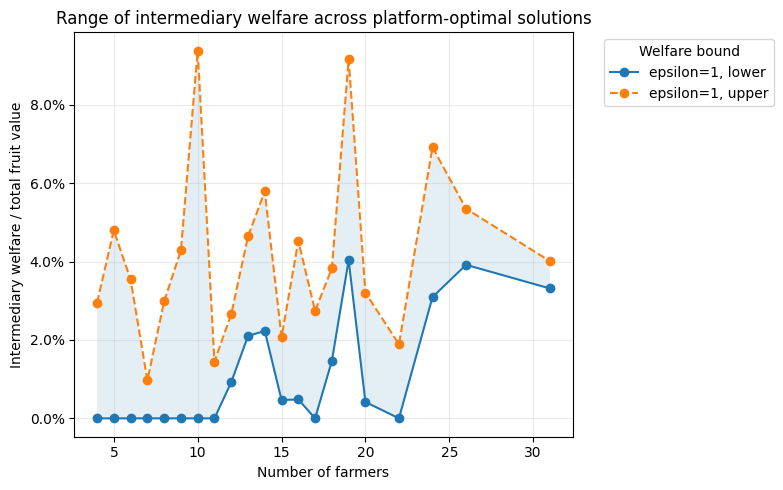

In [167]:
plot_welfare_range(
    df_gaps,
    lower_col="min_welfare_intermediaries",
    upper_col="max_welfare_intermediaries",
    ylabel="Intermediary welfare / total fruit value",
    title="Range of intermediary welfare across platform-optimal solutions"
)

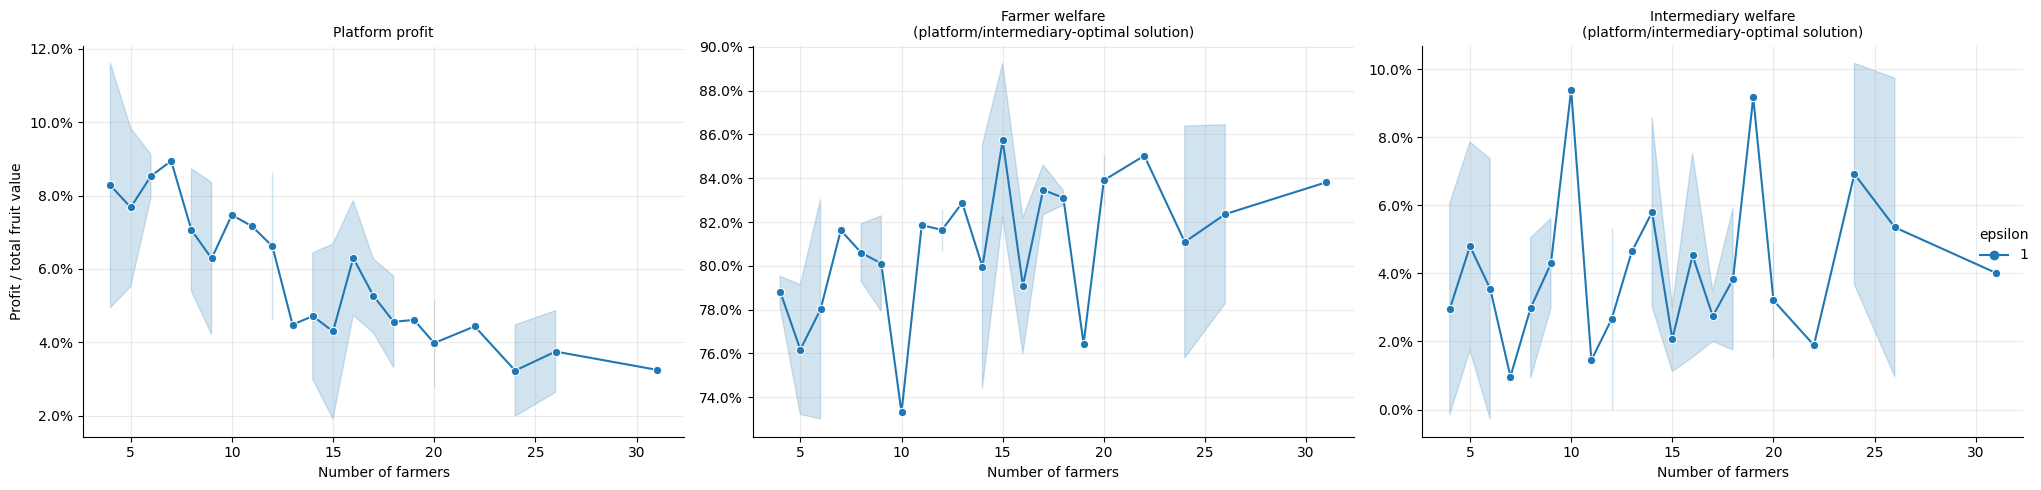

In [168]:


df_gaps["avg_epsilon"] = df_gaps["avg_epsilon"].astype(int)
df_gaps["n_farmers"] = df_gaps["n_farmers"].astype(int)

metric_cols = {
    "Platform profit": "profit_percentage",
    "Farmer welfare\n(platform/intermediary-optimal solution)": "min_welfare_farmers",
    "Intermediary welfare\n(platform/intermediary-optimal solution)": "max_welfare_intermediaries",
}

long_df = df_gaps.melt(
    id_vars=["avg_epsilon", "instance", "n_farmers"],
    value_vars=list(metric_cols.values()),
    var_name="metric",
    value_name="value",
)

long_df["metric"] = long_df["metric"].map({v: k for k, v in metric_cols.items()})

g = sns.relplot(
    data=long_df,
    x="n_farmers",
    y="value",
    hue="avg_epsilon",
    col="metric",
    kind="line",
    estimator="mean",
    errorbar="sd",
    marker="o",
    facet_kws={"sharey": False, "sharex": True},
    height=5.0,
    aspect=1.3,
)

g.set_axis_labels("Number of farmers", "Profit / total fruit value")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.grid(True, alpha=0.25)

g._legend.set_title("epsilon")
plt.tight_layout()
plt.show()

In [169]:
def plot_quadratic_average_trends(df):
    df_plot = df.copy()
    df_plot["avg_epsilon"] = df_plot["avg_epsilon"].astype(int)
    df_plot["n_intermediaries"] = df_plot["n_intermediaries"].astype(int)

    metric_cols = {
        "Farmer welfare": "min_welfare_farmers",
        "Intermediary welfare": "max_welfare_intermediaries",
    }

    for metric_label, metric_col in metric_cols.items():
        mean_df = (
            df_plot
            .groupby(["avg_epsilon", "n_intermediaries"], as_index=False)[metric_col]
            .mean()
        )

        sns.lmplot(
            data=mean_df,
            x="n_intermediaries",
            y=metric_col,
            hue="avg_epsilon",
            order=2,
            ci=None,
            height=4,
            aspect=1.4,
            scatter_kws={"s": 45},
            line_kws={"linewidth": 1.8},
        )

        plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
        plt.xlabel("Number of intermediaries")
        plt.ylabel(f"{metric_label} / total fruit value")
        plt.title(f"Quadratic trend in average {metric_label}")
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()

In [170]:
plot_quadratic_average_trends(df_gaps)

KeyError: 'n_intermediaries'

In [171]:
import statsmodels.formula.api as smf

def quadratic_regression_raw(df, metric_col):
    rows = []

    for eps, group in df.groupby("avg_epsilon"):
        g = group.copy()
        g["n_centered"] = g["n_intermediaries"] - g["n_intermediaries"].mean()
        g["n_centered_sq"] = g["n_centered"] ** 2

        model = smf.ols(
            f"{metric_col} ~ n_centered + n_centered_sq",
            data=g
        ).fit(cov_type="HC3")

        rows.append({
            "epsilon": eps,
            "metric": metric_col,
            "quadratic_coef": model.params["n_centered_sq"],
            "quadratic_se": model.bse["n_centered_sq"],
            "quadratic_pvalue": model.pvalues["n_centered_sq"],
            "linear_coef": model.params["n_centered"],
            "linear_pvalue": model.pvalues["n_centered"],
            "r_squared": model.rsquared,
        })

    return pd.DataFrame(rows)

In [19]:
farmer_quad_raw = quadratic_regression_raw(df_gaps, "min_welfare_farmers")
intermediary_quad_raw = quadratic_regression_raw(df_gaps, "max_welfare_intermediaries")

pd.concat([farmer_quad_raw, intermediary_quad_raw])

,epsilon,metric,quadratic_coef,quadratic_se,quadratic_pvalue,linear_coef,linear_pvalue,r_squared
0,1,min_welfare_farmers,-0.000380,0.000260,0.143831,0.001162,0.269593,0.086052
1,3,min_welfare_farmers,-0.000217,0.000118,0.066907,0.000697,0.139121,0.162262
2,5,min_welfare_farmers,-0.000131,0.000080,0.103506,0.000147,0.658120,0.090858
3,7,min_welfare_farmers,-0.000147,0.000095,0.122794,0.000428,0.262330,0.116512
0,1,max_welfare_intermediaries,0.000114,0.000187,0.543270,-0.000491,0.534407,0.024652
1,3,max_welfare_intermediaries,0.000056,0.000055,0.313222,-0.000289,0.203667,0.076163
2,5,max_welfare_intermediaries,0.000021,0.000031,0.507363,0.000169,0.167357,0.075278
3,7,max_welfare_intermediaries,0.000052,0.000050,0.291761,-0.000092,0.633826,0.047598


In [43]:
quad_results = pd.concat([farmer_quad, intermediary_quad], ignore_index=True)

mean_n = df_gaps["n_intermediaries"].mean()

quad_results["turning_point_n_intermediaries"] = (
    -quad_results["linear_coef"] / (2 * quad_results["quadratic_coef"])
    + mean_n
)

quad_results[
    [
        "epsilon",
        "metric",
        "quadratic_coef",
        "linear_coef",
        "turning_point_n_intermediaries",
    ]
]

,epsilon,metric,quadratic_coef,linear_coef,turning_point_n_intermediaries
0,1,min_welfare_farmers,-0.000380,0.001162,16.531209
1,3,min_welfare_farmers,-0.000217,0.000697,16.607235
2,5,min_welfare_farmers,-0.000131,0.000147,15.561768
3,7,min_welfare_farmers,-0.000147,0.000428,16.458510
4,1,max_welfare_intermediaries,0.000114,-0.000491,17.159888
5,3,max_welfare_intermediaries,0.000056,-0.000289,17.593921
6,5,max_welfare_intermediaries,0.000021,0.000169,10.945588
7,7,max_welfare_intermediaries,0.000052,-0.000092,15.879246


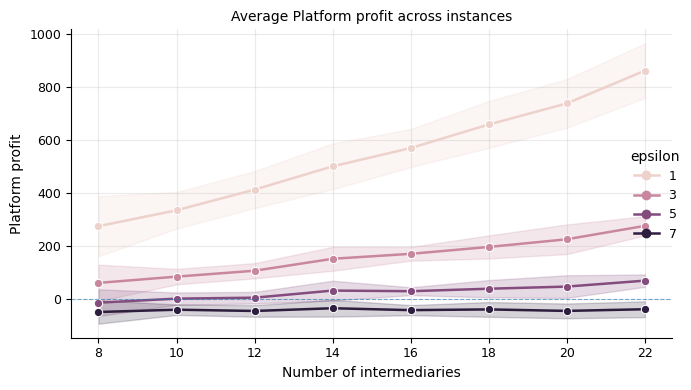

In [31]:
def plot_metric_averaged_across_instances_raw(df, metric_col, metric_label):
    df_plot = df.copy()
    df_plot["avg_epsilon"] = df_plot["avg_epsilon"].astype(int)
    df_plot["instance"] = df_plot["instance"].astype(int)
    df_plot["n_intermediaries"] = df_plot["n_intermediaries"].astype(int)

    g = sns.relplot(
        data=df_plot,
        x="n_intermediaries",
        y=metric_col,
        hue="avg_epsilon",
        kind="line",
        marker="o",
        estimator="mean",   # average across instances
        errorbar="sd",      # show std dev across instances
        sort=True,
        height=4,
        aspect=1.5,
        linewidth=1.8,
    )

    g.set_axis_labels("Number of intermediaries", metric_label)

    ax = g.ax
    ax.grid(True, alpha=0.25)
    ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.6)

    if g._legend is not None:
        g._legend.set_title("epsilon")

    plt.title(f"Average {metric_label} across instances")
    plt.tight_layout()
    plt.show()

plot_metric_averaged_across_instances_raw(
    df_gaps,
    "vanilla_profit",
    "Platform profit"
)

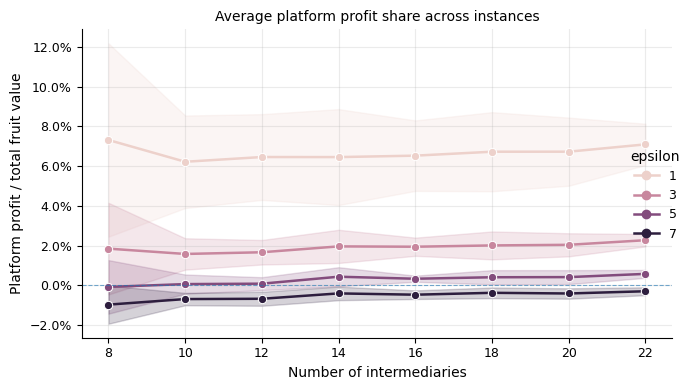

In [32]:
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import matplotlib.pyplot as plt

def plot_profit_share_averaged_across_instances(df):
    df_plot = df.copy()
    df_plot["avg_epsilon"] = df_plot["avg_epsilon"].astype(int)
    df_plot["instance"] = df_plot["instance"].astype(int)
    df_plot["n_intermediaries"] = df_plot["n_intermediaries"].astype(int)

    g = sns.relplot(
        data=df_plot,
        x="n_intermediaries",
        y="profit_percentage",
        hue="avg_epsilon",
        kind="line",
        marker="o",
        estimator="mean",   # average across instances
        errorbar="sd",      # std dev across instances
        sort=True,
        height=4,
        aspect=1.5,
        linewidth=1.8,
    )

    g.set_axis_labels(
        "Number of intermediaries",
        "Platform profit / total fruit value"
    )

    ax = g.ax
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.grid(True, alpha=0.25)

    if g._legend is not None:
        g._legend.set_title("epsilon")

    plt.title("Average platform profit share across instances")
    plt.tight_layout()
    plt.show()

plot_profit_share_averaged_across_instances(df_gaps)

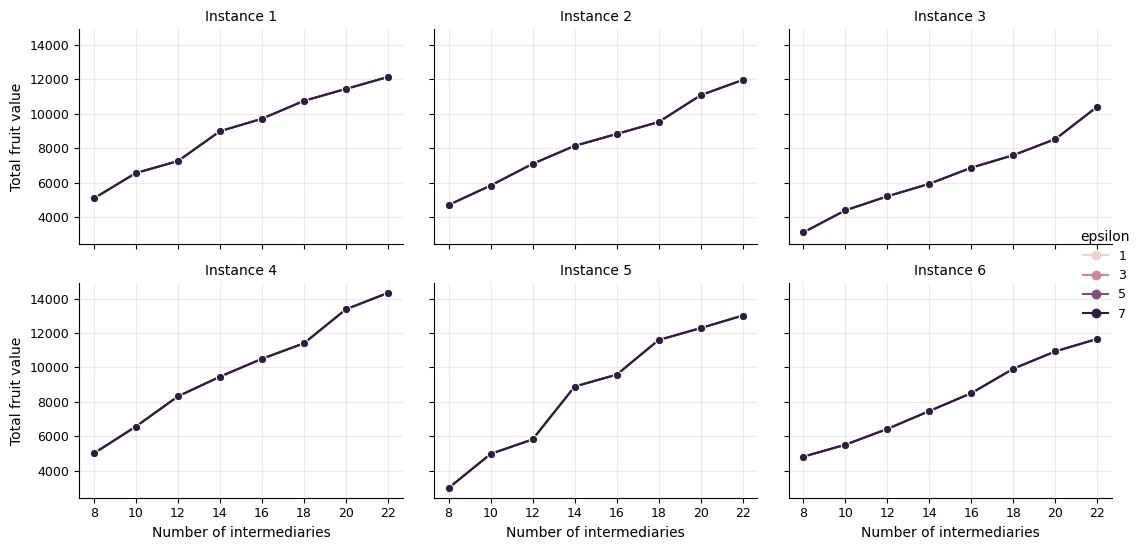

In [25]:
plot_metric_one_panel_per_instance_raw(
    df_gaps,
    "fruit_value",
    "Total fruit value"
)

In [56]:

actual_costs_platform = {0: 0.0775829869015126,
 1: 0.07768902868743288,
 2: 0.07792714074761442,
 3: 0.07779050019770295,
 4: 0.07780432119364723,
 5: 0.07780432119364725,
 6: 0.07758298690151258,
 7: 0.07758298690151257,
 8: 0.07758298690151258,
 9: 0.0775829869015126,
 }

actual_costs_improvement = {i: actual_costs_platform[i] - actual_costs_platform[0] for i in range(1, 10)}

actual_perc_platform = {0: 0.09959740695143612,
 1: 0.044517655245960054,
 2: 0.022845478696154217,
 3: 0.011845342163052535,
 4: 0.005042216382378989,
 5: 0.0009595428605521555,
 6: -0.002270061056467741,
 7: -0.004516052387438745,
 8: -0.005835568402234102,
 9: -0.007022154488203626}

actual_max_int = {0: 0.32758953661755996,
 1: 0.04175691614041955,
 2: 0.02060091126517644,
 3: 0.013039289559810586,
 4: 0.009350912870058112,
 5: 0.007924168304404811,
 6: 0.00772484422378011,
 7: 0.007443614889069343,
 8: 0.0063391957909994575,
 9: 0.005711990106601736}

actual_min_int = {0: 0.0,
 1: 0.01478574070810623,
 2: 0.007534357335050608,
 3: 0.007899933576455203,
 4: 0.005905858766726449,
 5: 0.006235383720283765,
 6: 0.0058198497457951585,
 7: 0.0073826381391337735,
 8: 0.006322061118747919,
 9: 0.00571137535532129}

actual_min_farmer = {0: 0.4952300812484759,
 1: 0.8360364116451723,
 2: 0.8786264810100395,
 3: 0.8973248797984186,
 4: 0.9078025612729003,
 5: 0.9133119793603803,
 6: 0.9169622416501595,
 7: 0.9194894623158415,
 8: 0.9219133974287067,
 9: 0.9237271891990739}

actual_max_farmer = {0: 0.8228196178660359,
 1: 0.8630075870774853,
 2: 0.8916930349401653,
 3: 0.9024642357817737,
 4: 0.911247615376232,
 5: 0.9150007639445015,
 6: 0.9188672361281446,
 7: 0.9195504390657769,
 8: 0.9219305321009583,
 9: 0.9237278039503545}



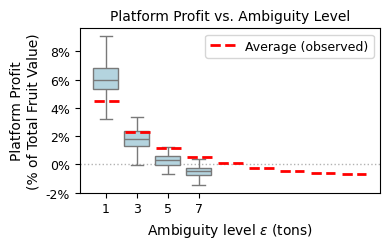

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

df_gaps = df_gaps.query("avg_epsilon >= 1.0")

plt.figure(figsize=(4, 2.6))

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Boxplot without outliers
ax = sns.boxplot(
    data=df_gaps, 
    x="avg_epsilon", 
    y="profit_percentage", 
    zorder=1, 
    showfliers=False,
    color="lightblue"
)

# Add horizontal reference line at 0% (lighter solid line)
plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

# Overlay observed value per category with a dashed line
for i, category in enumerate(list(range(1, 10))):
    obs = actual_perc_platform.get(category, None)
    if obs is not None:
        plt.plot(
            [i - 0.38, i + 0.42], 
            [obs, obs], 
            color="red", 
            linewidth=2, 
            linestyle="--",  # Dashed line for the average
            label="Average (observed)" if i == 0 else "", 
            zorder=10
        )

# Format y-axis as percentages
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Clean and informative labels
plt.ylabel("Platform Profit\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit vs. Ambiguity Level")

# Only show one legend entry for the observed line
handles, labels = ax.get_legend_handles_labels()
if handles:
    plt.legend(handles[:1], labels[:1], loc="upper right")

plt.tight_layout()
plt.savefig("../figures/platform_profit.pdf", bbox_inches='tight')
plt.show()

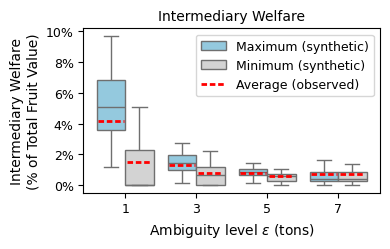

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually to ensure consistency
palette = {
    "Maximum (synthetic)": "skyblue", 
    "Minimum (synthetic)": "lightgray"
}

# Melt the dataframe
df_melted = df_gaps.melt(
    id_vars='avg_epsilon', 
    value_vars=['max_welfare_intermediaries', 'min_welfare_intermediaries'], 
    var_name='Welfare Type', 
    value_name='Welfare'
)

# Improve category names for legend
df_melted['Welfare Type'] = df_melted['Welfare Type'].map({
    'max_welfare_intermediaries': 'Maximum (synthetic)', 
    'min_welfare_intermediaries': 'Minimum (synthetic)'
})

# Create boxplot
plt.figure(figsize=(4, 2.6))
ax = sns.boxplot(
    data=df_melted, 
    x="avg_epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette=palette, 
    showfliers=False
)

# Overlay actual data lines with red dashed lines for averages
for i, category in enumerate(sorted(df_gaps["avg_epsilon"].unique())):
    obs_max = actual_max_int.get(category, None)
    obs_min = actual_min_int.get(category, None)
    if obs_max is not None:
        line, = plt.plot(
            [i - 0.38, i - 0.02], [obs_max, obs_max], 
            color="red", linewidth=2, linestyle="--", 
            label="Average (observed)" if i == 0 else "", zorder=10
        )
        line.set_dashes([2, 1])
    if obs_min is not None:
        line, = plt.plot(
            [i + 0.02, i + 0.38], [obs_min, obs_min], 
            color="red", linewidth=2, linestyle="--", 
            label=None, zorder=10
        )
        line.set_dashes([2, 1])

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Labeling
plt.ylabel("Intermediary Welfare\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Intermediary Welfare")

# Legend cleanup
handles, labels = ax.get_legend_handles_labels()
# Deduplicate legend and ensure all three entries are present
unique = dict(zip(labels, handles))
plt.legend(
    [unique["Maximum (synthetic)"], unique["Minimum (synthetic)"], unique["Average (observed)"]],
    ["Maximum (synthetic)", "Minimum (synthetic)", "Average (observed)"],
    title="", loc="upper right"
)

plt.tight_layout()
plt.savefig("../figures/intermediary_welfare.pdf", bbox_inches='tight')
plt.show()

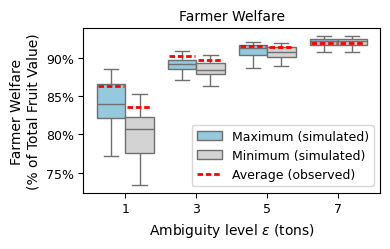

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually to ensure consistency
palette = {
    "Maximum (simulated)": "skyblue", 
    "Minimum (simulated)": "lightgray"
}

# Melt the dataframe
df_melted = df_gaps.melt(
    id_vars='avg_epsilon', 
    value_vars=['max_welfare_farmers', 'min_welfare_farmers'], 
    var_name='Welfare Type', 
    value_name='Welfare'
)

# Improve category names for legend
df_melted['Welfare Type'] = df_melted['Welfare Type'].map({
    'max_welfare_farmers': 'Maximum (simulated)', 
    'min_welfare_farmers': 'Minimum (simulated)'
})

# Create boxplot
plt.figure(figsize=(4, 2.6))  # Adjusted figsize
ax = sns.boxplot(
    data=df_melted, 
    x="avg_epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette=palette, 
    showfliers=False
)

# Overlay actual data lines with red dashed lines for averages
for i, category in enumerate(sorted(df_gaps["avg_epsilon"].unique())):
    obs_max = actual_max_farmer.get(category, None)
    obs_min = actual_min_farmer.get(category, None)
    if obs_max is not None:
        line, = plt.plot(
            [i - 0.38, i - 0.02], [obs_max, obs_max], 
            color="red", linewidth=2, linestyle="--", 
            label="Average (observed)" if i == 0 else "", zorder=10
        )
        line.set_dashes([2, 1])  # Custom dash pattern: short dash, small gap
    if obs_min is not None:
        line, = plt.plot(
            [i + 0.02, i + 0.38], [obs_min, obs_min], 
            color="red", linewidth=2, linestyle="--", 
            label=None, zorder=10
        )
        line.set_dashes([2, 1])  # Custom dash pattern: short dash, small gap

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Labeling
plt.ylabel("Farmer Welfare\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Farmer Welfare")

# Legend cleanup
handles, labels = ax.get_legend_handles_labels()
# Deduplicate legend and ensure all three entries are present
unique = dict(zip(labels, handles))
plt.legend(
    [unique["Maximum (simulated)"], unique["Minimum (simulated)"], unique["Average (observed)"]],
    ["Maximum (simulated)", "Minimum (simulated)", "Average (observed)"],
    title="", loc="lower right"
)

plt.tight_layout()
plt.savefig("../figures/farmer_welfare.pdf", bbox_inches='tight')
plt.show()

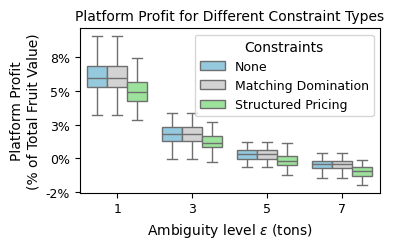

In [60]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

import matplotlib.pyplot as plt

# Melt the dataframe for easier plotting
profit_data = df_gaps.melt(
    id_vars='avg_epsilon', 
    value_vars=['vanilla_profit_by_fruit_value', 'domination_profit_by_fruit_value', 'structured_profit_by_fruit_value'], 
    var_name='Constraints', 
    value_name='Profit'
)

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually for consistency
palette = {
    "None": "skyblue", 
    "Matching Domination": "lightgray", 
    "Structured Pricing": "lightgreen"
}

# Improve category names for legend
profit_data['Constraints'] = profit_data['Constraints'].map({
    'vanilla_profit_by_fruit_value': 'None', 
    'domination_profit_by_fruit_value': 'Matching Domination', 
    'structured_profit_by_fruit_value': 'Structured Pricing'
})

# Create the boxplot
plt.figure(figsize=(4, 2.6))
ax = sns.boxplot(
    data=profit_data, 
    x="avg_epsilon", 
    y="Profit", 
    hue="Constraints", 
    palette=palette, 
    showfliers=False
)

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))

# Labeling
plt.ylabel("Platform Profit\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit for Different Constraint Types")
# Format y-axis as percentages
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Adjust legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Constraints", loc="upper right")

plt.tight_layout()
plt.savefig("../figures/profit_by_contraint.pdf", bbox_inches='tight')
plt.show()